In [8]:
import sys 
sys.path.append("../src")
from data_loader import load_prices, load_returns 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

prices = load_prices()
log_returns = load_returns()

print(prices.shape)
print(log_returns.shape)

(1509, 41)
(1508, 41)


In [9]:
# computation of the correlation matrix
corr_matrix = log_returns.corr()
print(corr_matrix.shape)
print(corr_matrix.head(3))

(41, 41)
Ticker      AAPL       ABT      AMZN       AXP       BAC         C       CAT  \
Ticker                                                                         
AAPL    1.000000  0.522928  0.625221  0.482854  0.456982  0.465372  0.413594   
ABT     0.522928  1.000000  0.416366  0.427996  0.435088  0.399297  0.391085   
AMZN    0.625221  0.416366  1.000000  0.351852  0.330763  0.325662  0.308442   

Ticker        CL       COP      COST  ...       PFE        PG      PYPL  \
Ticker                                ...                                 
AAPL    0.357590  0.333702  0.554040  ...  0.326316  0.414790  0.576789   
ABT     0.490963  0.256188  0.484167  ...  0.445466  0.509705  0.462035   
AMZN    0.257655  0.210400  0.508948  ...  0.226895  0.249740  0.570142   

Ticker       SLB       TGT       UNH         V       WFC       WMT       XOM  
Ticker                                                                        
AAPL    0.293242  0.383979  0.464809  0.629038  0.398778

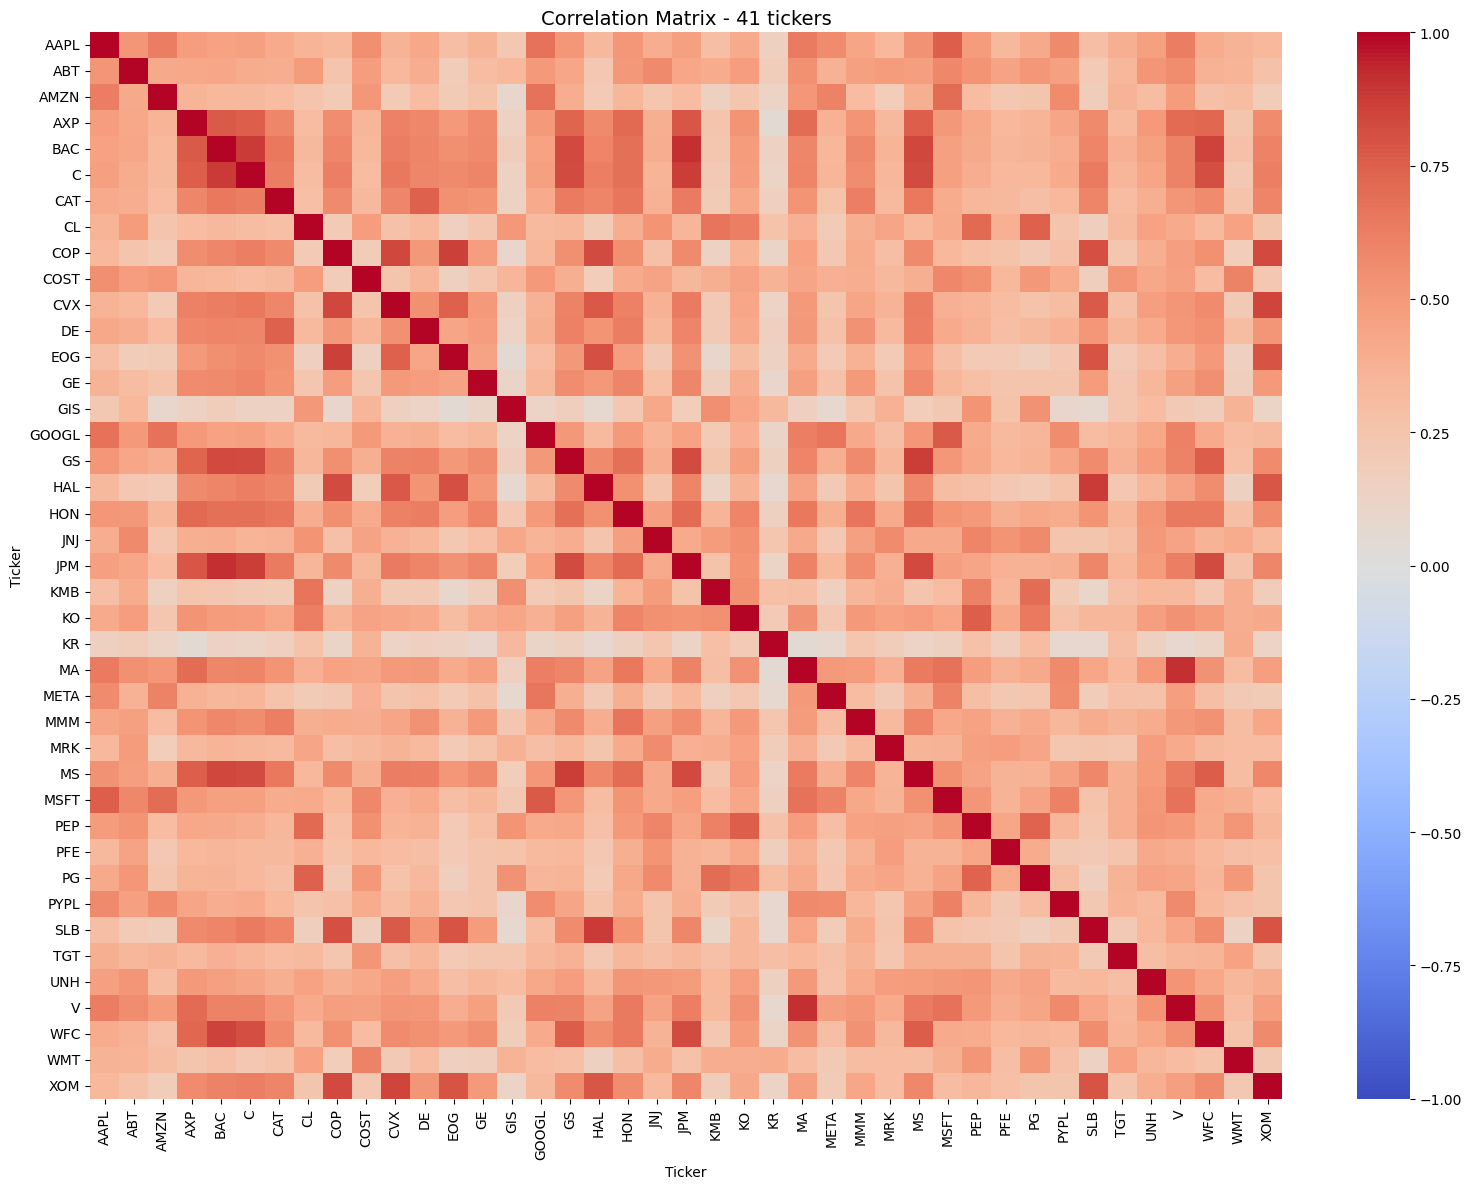

In [10]:
# correlation heatmap

fig, ax = plt.subplots(figsize = (16,12))

sns.heatmap(corr_matrix , annot = False , cmap = 'coolwarm' , center = 0 , vmin = -1 , vmax = 1,ax=ax)
ax.set_title("Correlation Matrix - 41 tickers" , fontsize = 14)
plt.tight_layout()
plt.savefig("../data.correlation_heatmap.png", dpi = 120)
plt.show()


In [11]:
# extraction of highly correlated pairs
pairs = []
tickers = corr_matrix.columns.tolist()

for i in  range(len(tickers)):
    for j  in range(i+1 , len(tickers)):
        r = corr_matrix.iloc[i,j]
        if r >0.8:
            pairs.append((tickers[i] , tickers[j],round(r,4)))

pairs_df = pd.DataFrame(pairs ,columns = ["ticker_1", "ticker_2", "correlation"])
pairs_df = pairs_df.sort_values("correlation",ascending = False ).reset_index(drop = True)
print(f"Total pairs above 0.8 correlation: {len(pairs_df)}")
print(pairs_df.head(15))

Total pairs above 0.8 correlation: 22
   ticker_1 ticker_2  correlation
0        MA        V       0.9127
1       BAC      JPM       0.9078
2       BAC        C       0.8783
3       HAL      SLB       0.8782
4        GS       MS       0.8712
5         C      JPM       0.8681
6       COP      EOG       0.8665
7       BAC      WFC       0.8547
8       CVX      XOM       0.8474
9       BAC       MS       0.8436
10      COP      CVX       0.8422
11      BAC       GS       0.8345
12      JPM       MS       0.8342
13      COP      XOM       0.8340
14       GS      JPM       0.8266


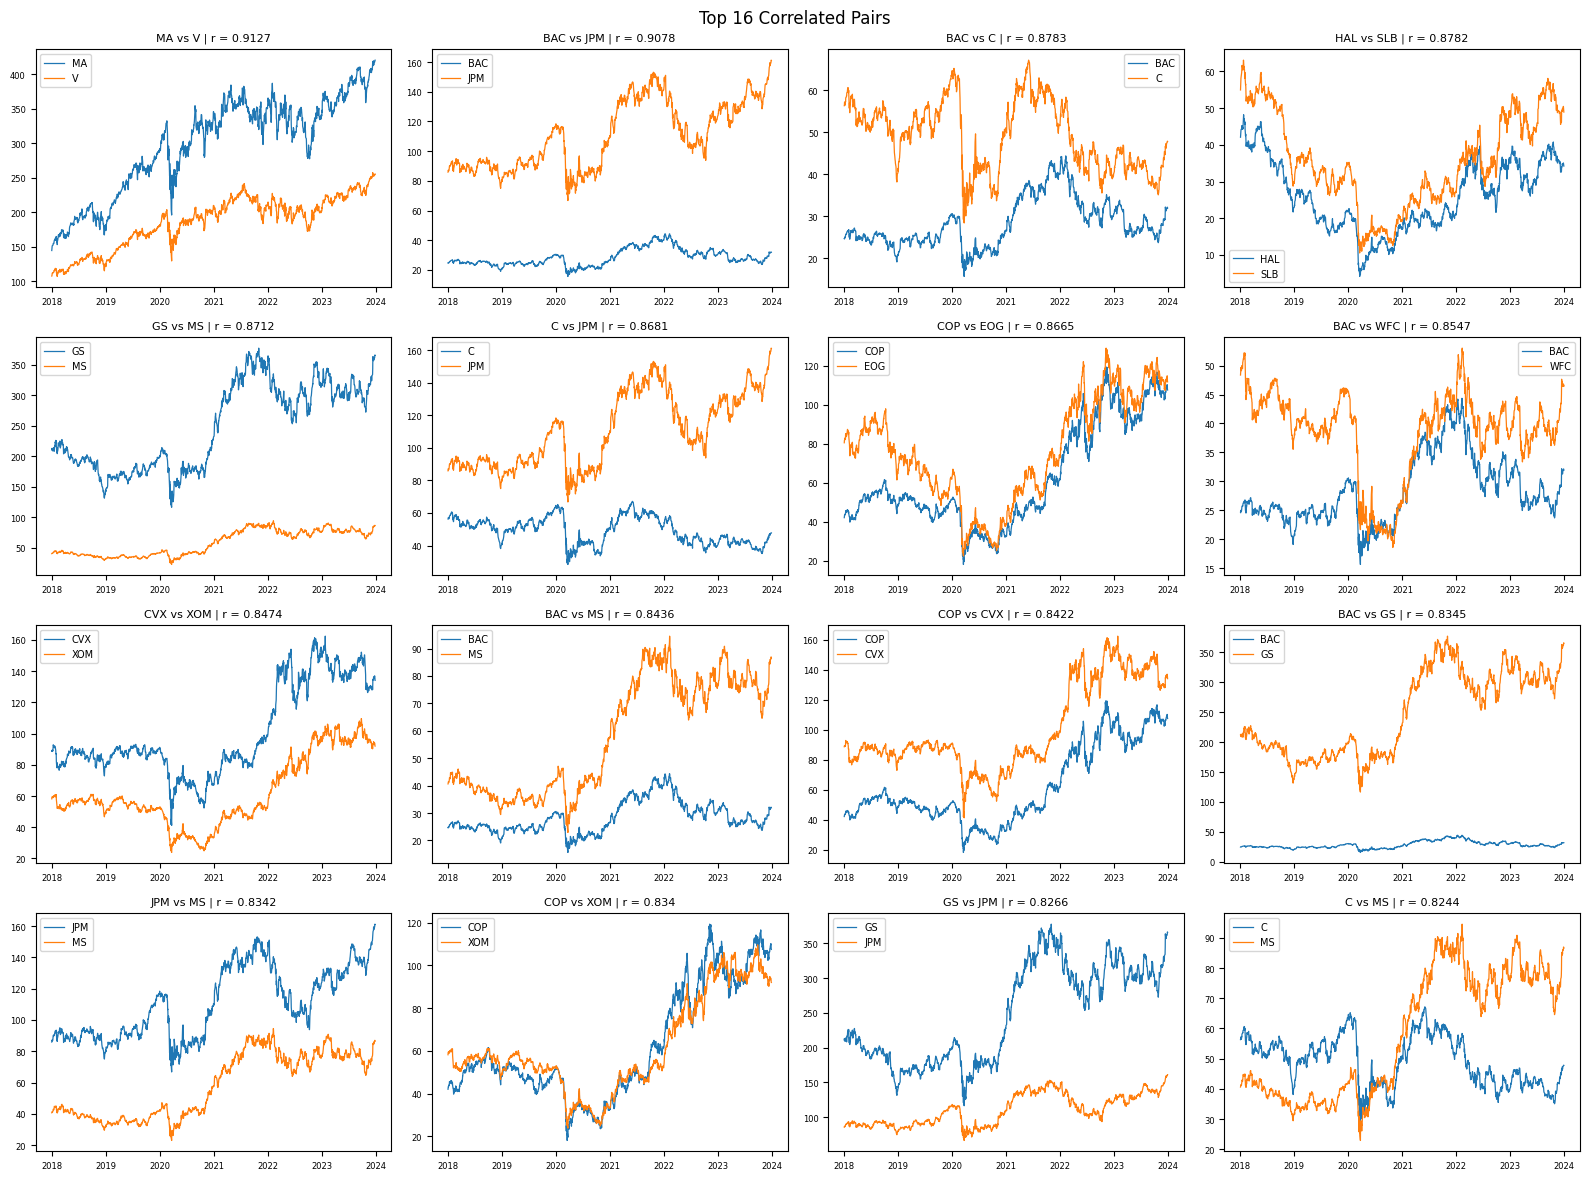

In [12]:
# visualization of the filtered pairs

fig,axes = plt.subplots(4,4,figsize=(16,12))
axes = axes.flatten()
for i,row in pairs_df.head(16).iterrows():
    ax= axes[i]
    ax.plot(prices.index , prices[row["ticker_1"]] , label = row["ticker_1"],linewidth=0.9)
    ax.plot(prices.index,prices[row["ticker_2"]] , label = row["ticker_2"] , linewidth = 0.9)
    ax.set_title(f"{row["ticker_1"]} vs {row['ticker_2']} | r = {row['correlation']}" , fontsize = 8)
    ax.legend(fontsize = 7)
    ax.tick_params(labelsize = 6)

plt.suptitle('Top 16 Correlated Pairs')
plt.tight_layout()
plt.savefig("../data/correlated_pairs.png" , dpi = 120)
plt.show()

In [13]:
pairs_df.to_csv('../data/correlated_pairs.csv',index =False)
verify = pd.read_csv('../data/correlated_pairs.csv')
print(verify.shape)
print(verify.head())

(22, 3)
  ticker_1 ticker_2  correlation
0       MA        V       0.9127
1      BAC      JPM       0.9078
2      BAC        C       0.8783
3      HAL      SLB       0.8782
4       GS       MS       0.8712


In [14]:
from data_loader import compute_correlation

corr_matrix , pairs_df = compute_correlation(log_returns)
print(f"Pairs found: {len(pairs_df)}")

Pairs found: 22
